In [1]:
import numpy as np, curvedsky as cs, plottools as pl, cmb as CMB, cosmology, healpy as hp
from matplotlib.pyplot import *
import warnings
warnings.filterwarnings("ignore")
ac2rad  = np.pi/10800.
deg2rad = np.pi/180.
Tcmb  = CMB.Tcmb    # CMB temperature

In [9]:
freq = 100
freqn = {100: 0, 143: 1, 217: 2, 353: 3}

In [2]:
Lmax  = 3000       # maximum multipole of output normalization
rlmin, rlmax = 50, Lmax  # CMB multipole range for reconstruction
L = np.linspace(0,Lmax,Lmax+1)
Lfac = L*(L+1)/2/np.pi

In [3]:
lcl = CMB.read_camb_cls('data_local/cosmo2017_10K_acc3_lensedCls.dat',ftype='lens',output='array')[:,:Lmax+1]

In [28]:
Q1 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_353_2048_R3.01_halfmission-1.fits',field=1)
U1 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_353_2048_R3.01_halfmission-1.fits',field=2)

In [29]:
Q2 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_353_2048_R3.01_halfmission-2.fits',field=1)
U2 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_353_2048_R3.01_halfmission-2.fits',field=2)

In [30]:
Mpix1 = Q1.copy()
Mpix1[Mpix1>-1e30] = 1.
Mpix1[Mpix1!=1] = 0.
Mpix2 = Q2.copy()
Mpix2[Mpix2>-1e30] = 1.
Mpix2[Mpix2!=1] = 0.

In [32]:
MptsrI = hp.fitsfunc.read_map('data/mask/HFI_Mask_PointSrc_2048_R2.00.fits',hdu=1,field=freqn[freq]) #100-353
MptsrP = hp.fitsfunc.read_map('data/mask/HFI_Mask_PointSrc_2048_R2.00.fits',hdu=2,field=freqn[freq]) #100-353
Mptsr = MptsrI*MptsrP

0.9826202392578125


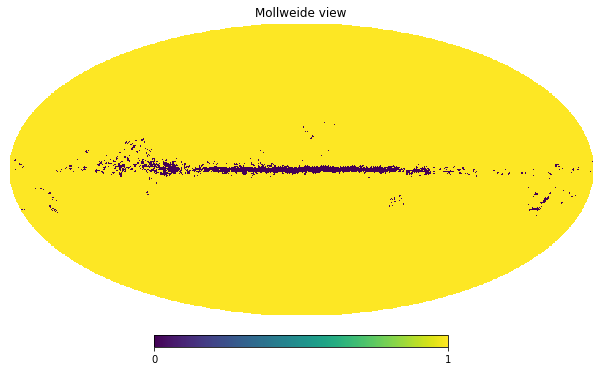

In [19]:
if freq!=143:
    McoI = hp.read_map('data/mask/HFI_BiasMap_'+str(freq)+'-CO-noiseRatio_2048_R3.00_full.fits',field=0)
    McoQ = hp.read_map('data/mask/HFI_BiasMap_'+str(freq)+'-CO-noiseRatio_2048_R3.00_full.fits',field=1)
    McoU = hp.read_map('data/mask/HFI_BiasMap_'+str(freq)+'-CO-noiseRatio_2048_R3.00_full.fits',field=2)
    McoI[McoI<-2] = 0.
    McoI[McoI!=0] = 1.
    McoQ[McoQ<-2] = 0.
    McoQ[McoQ!=0] = 1.
    McoU[McoU<-2] = 0.
    McoU[McoU!=0] = 1.
    Mco = (1.-McoQ)*(1.-McoU)*(1.-McoI)
    hp.mollview(Mco)
    print(np.mean(Mco))
else:
    Mco = 1.

In [33]:
mask1 = Mco*Mptsr*Mpix1
mask2 = Mco*Mptsr*Mpix2

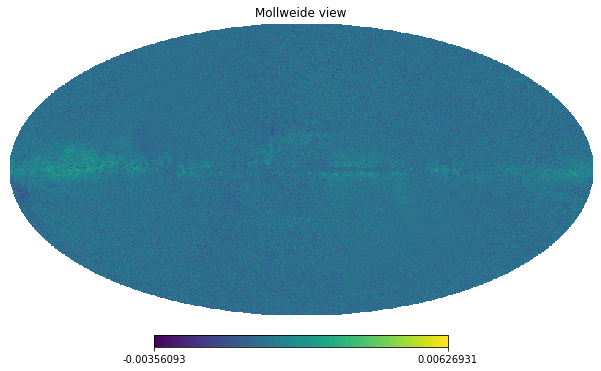

In [34]:
hp.mollview(mask1*Q1)

In [35]:
nside = 2048
lmax  = 2048
Elm1, Blm1 = cs.utils.hp_map2alm_spin(nside,lmax,lmax,2,mask1*Q1,mask1*U1)
Elm2, Blm2 = cs.utils.hp_map2alm_spin(nside,lmax,lmax,2,mask2*Q2,mask2*U2)

In [38]:
EE = cs.utils.alm2cl(lmax,Elm1,Elm2)
EB = ( cs.utils.alm2cl(lmax,Elm1,Blm2) + cs.utils.alm2cl(lmax,Elm2,Blm1) ) * .5
BB = cs.utils.alm2cl(lmax,Blm1,Blm2)

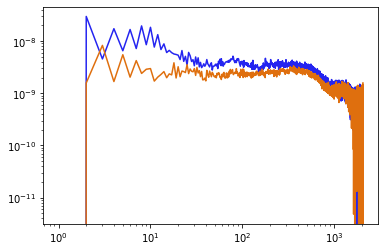

In [40]:
Ls = np.linspace(0,lmax,lmax+1)
fac = Ls*(Ls+1)/2/np.pi
xscale('log')
yscale('log')
plot(fac*EE)
plot(fac*BB)

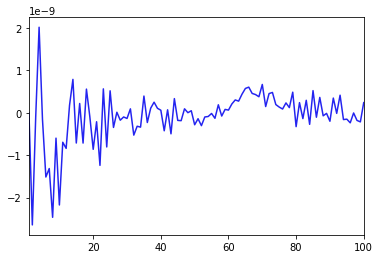

In [42]:
xlim(1,100)
plot(fac*EB)